# Retention and Cohort Analysis

## Objective

In this notebook, I look at how users come back to the game after they join.

I will focus on:

- overall retention after join
- weekly cohort retention patterns
- D1, D3, D7, D14, and D30 retention
- retention differences by OS and country
- the link between first-week activity and later retention


In [16]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load data and analysis scope

I use `users` and `user_sessions` in this notebook.

For retention:

- `join_date` from `users` is the cohort start
- a user is retained on a day if the user has at least one session on that day
- eligible user logic is used in every retention calculation
- because of the session observation window, very new cohorts cannot be used for longer-term retention days


In [17]:
data_dir = Path('csv_files')

users = pd.read_csv(data_dir / 'users.csv')
sessions = pd.read_csv(data_dir / 'user_sessions.csv')

users['user_id'] = pd.to_numeric(users['user_id'], errors='coerce').astype('Int64')
users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce').dt.normalize()
users['country'] = users['country'].fillna('Unknown')

sessions['user_id'] = pd.to_numeric(sessions['user_id'], errors='coerce').astype('Int64')
sessions['dt'] = pd.to_datetime(sessions['dt'], errors='coerce').dt.normalize()
sessions['session_duration_sec'] = pd.to_numeric(sessions['session_duration_sec'], errors='coerce')

users_clean = users.drop_duplicates(subset=['user_id']).copy()
sessions_clean = sessions[sessions['user_id'].isin(users_clean['user_id'])].copy()
sessions_clean = sessions_clean[
    sessions_clean['dt'].notna() &
    sessions_clean['session_duration_sec'].notna() &
    (sessions_clean['session_duration_sec'] >= 0)
].copy()

session_start = sessions_clean['dt'].min()
session_end = sessions_clean['dt'].max()

retention_users = users_clean[
    users_clean['join_date'].between(session_start, session_end)
].copy()

scope_df = pd.DataFrame(
    {
        'metric': [
            'users in users table',
            'users in retention base',
            'users outside retention base',
            'session window start',
            'session window end',
        ],
        'value': [
            users_clean['user_id'].nunique(dropna=True),
            retention_users['user_id'].nunique(dropna=True),
            users_clean['user_id'].nunique(dropna=True) - retention_users['user_id'].nunique(dropna=True),
            session_start.date(),
            session_end.date(),
        ],
    }
)

display(scope_df)


,metric,value
0,users in users table,6584
1,users in retention base,4268
2,users outside retention base,2316
3,session window start,2022-06-02
4,session window end,2022-12-28


### Comment

- I use only users whose `join_date` is inside the session data window. This removes older users whose early lifecycle is not visible in the session table. Because of that, the retention base is smaller than the full `users` table, but it is safer for cohort analysis.


## 2. Retention metric definition

Retention in this notebook is based on exact days after join.

- Day 0: the day the user joined
- Day N retention: the user had at least one session exactly N days after join
- one user can have many sessions in one day, but it still counts as one retained day
- for Day N retention, only users who can be observed for at least N days are in the denominator

Example:

- if a user joined 3 days ago, that user can be used for D1 and D3
- the same user cannot be used in D7 or D14 yet

## 3. Data preparation for retention

Now I build the user-day activity table for retention analysis.


In [18]:
retention_users['cohort_day'] = retention_users['join_date']
retention_users['cohort_week'] = retention_users['join_date'].dt.to_period('W').dt.start_time

# One row per user and activity day.
daily_activity = (
    sessions_clean[['user_id', 'dt']]
    .drop_duplicates()
    .rename(columns={'dt': 'activity_date'})
)

daily_activity = retention_users[
    ['user_id', 'join_date', 'cohort_day', 'cohort_week', 'os', 'country']
].merge(
    daily_activity,
    on='user_id',
    how='left'
)

daily_activity['days_since_join'] = (
    daily_activity['activity_date'] - daily_activity['join_date']
).dt.days

daily_activity = daily_activity[
    daily_activity['days_since_join'].notna() &
    (daily_activity['days_since_join'] >= 0)
].copy()

daily_activity['days_since_join'] = daily_activity['days_since_join'].astype(int)

prep_df = pd.DataFrame(
    {
        'metric': [
            'retention users',
            'users with any activity in retention base',
            'user-day activity rows',
            'max days since join in activity table',
        ],
        'value': [
            retention_users['user_id'].nunique(dropna=True),
            daily_activity['user_id'].nunique(dropna=True),
            len(daily_activity),
            daily_activity['days_since_join'].max(),
        ],
    }
)

display(prep_df)
display(daily_activity[['user_id', 'join_date', 'activity_date', 'days_since_join']].head(10))


def calculate_retention_curve(base_users, activity_df, end_date, group_col=None, max_day=30):
    records = []

    if group_col is None:
        grouped = [('All users', base_users)]
    else:
        grouped = base_users.groupby(group_col, observed=False)

    for group_value, group_users in grouped:
        user_ids = set(group_users['user_id'])
        group_activity = activity_df[activity_df['user_id'].isin(user_ids)]

        for day in range(max_day + 1):
            eligible_ids = group_users.loc[
                group_users['join_date'] <= end_date - pd.Timedelta(days=day),
                'user_id'
            ]
            eligible_users = eligible_ids.nunique()

            if eligible_users == 0:
                retained_users = np.nan
                retention_rate = np.nan
            else:
                retained_users = group_activity.loc[
                    group_activity['days_since_join'] == day,
                    'user_id'
                ].nunique()
                retention_rate = retained_users / eligible_users

            row = {
                'day': day,
                'eligible_users': eligible_users,
                'retained_users': retained_users,
                'retention_rate': retention_rate,
            }
            if group_col is not None:
                row[group_col] = group_value
            records.append(row)

    return pd.DataFrame(records)


def format_retention_table(df, group_cols=None):
    out = df.copy()
    out['retention_rate_pct'] = (out['retention_rate'] * 100).round(1)
    if group_cols is None:
        group_cols = []
    return out[group_cols + ['day', 'eligible_users', 'retained_users', 'retention_rate_pct']]


,metric,value
0,retention users,4268
1,users with any activity in retention base,4268
2,user-day activity rows,339191
3,max days since join in activity table,209


,user_id,join_date,activity_date,days_since_join
0,583785,2022-06-25,2022-06-25,0
1,583785,2022-06-25,2022-06-26,1
2,948940,2022-09-19,2022-09-24,5
3,948940,2022-09-19,2022-09-25,6
4,948940,2022-09-19,2022-09-19,0
5,1141021,2022-12-25,2022-12-28,3
6,1141021,2022-12-25,2022-12-26,1
7,1141021,2022-12-25,2022-12-25,0
8,1141021,2022-12-25,2022-12-27,2
9,535442,2022-06-03,2022-09-03,92


### Comment

- This activity table is the main retention table for the notebook. It has one row per user and activity day, so many sessions on the same day do not inflate retention.
- `days_since_join` is the key field for every retention chart and table below.


## 4. Cohort overview

Before I calculate retention, I want to see cohort size over time.


,metric,value
0,daily cohorts,198
1,weekly cohorts,30
2,largest weekly cohort,330
3,smallest weekly cohort,4


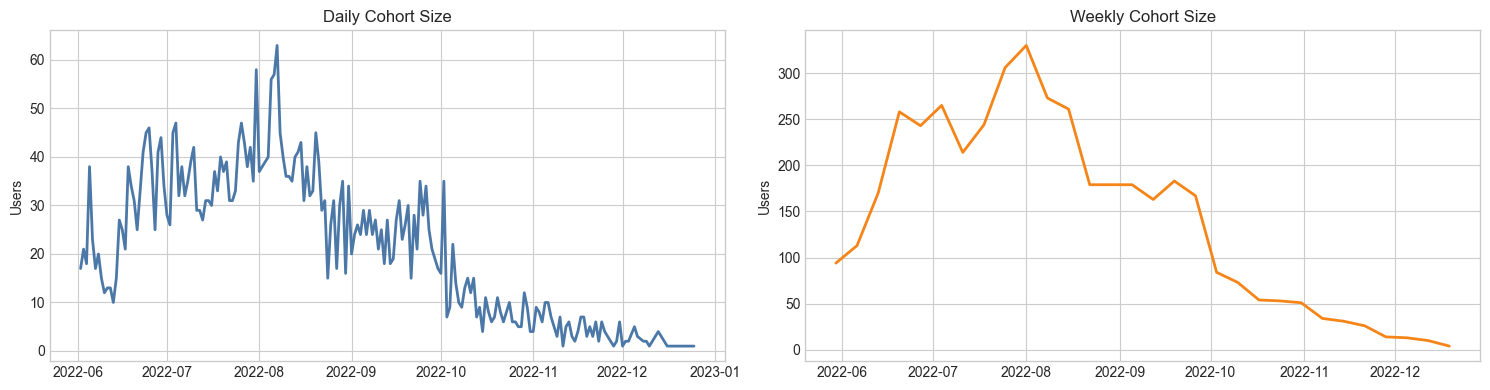

In [19]:
daily_cohort = (
    retention_users
    .groupby('cohort_day')['user_id']
    .nunique()
    .reset_index(name='cohort_size')
)

weekly_cohort = (
    retention_users
    .groupby('cohort_week')['user_id']
    .nunique()
    .reset_index(name='cohort_size')
)

cohort_overview_df = pd.DataFrame(
    {
        'metric': [
            'daily cohorts',
            'weekly cohorts',
            'largest weekly cohort',
            'smallest weekly cohort',
        ],
        'value': [
            daily_cohort['cohort_day'].nunique(),
            weekly_cohort['cohort_week'].nunique(),
            weekly_cohort['cohort_size'].max(),
            weekly_cohort['cohort_size'].min(),
        ],
    }
)

display(cohort_overview_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(daily_cohort['cohort_day'], daily_cohort['cohort_size'], color='#4C78A8', linewidth=2)
axes[0].set_title('Daily Cohort Size')
axes[0].set_ylabel('Users')

axes[1].plot(weekly_cohort['cohort_week'], weekly_cohort['cohort_size'], color='#F58518', linewidth=2)
axes[1].set_title('Weekly Cohort Size')
axes[1].set_ylabel('Users')

plt.tight_layout()
plt.show()


### Comment

- Cohort size is not flat over time.
- The stronger cohort period is around summer 2022, while later cohorts are much smaller.

## 5. Overall retention calculation

First, I calculate overall retention for all users in the retention base.


,day,eligible_users,retained_users,retention_rate_pct
0,0,4268,4260,99.80
1,1,4268,3711,86.90
3,3,4268,3590,84.10
7,7,4265,3519,82.50
14,14,4261,3391,79.60
30,30,4228,3032,71.70


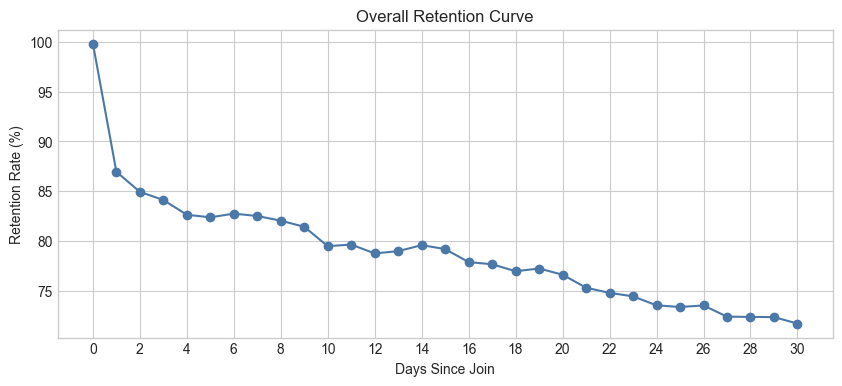

In [20]:
overall_retention = calculate_retention_curve(
    retention_users,
    daily_activity,
    session_end,
    max_day=30,
)

overall_milestones = format_retention_table(
    overall_retention[overall_retention['day'].isin([0, 1, 3, 7, 14, 30])]
)

display(overall_milestones)

plt.figure(figsize=(10, 4))
plt.plot(overall_retention['day'], overall_retention['retention_rate'] * 100, marker='o', color='#4C78A8')
plt.title('Overall Retention Curve')
plt.xlabel('Days Since Join')
plt.ylabel('Retention Rate (%)')
plt.xticks(range(0, 31, 2))
plt.show()


### Comment

- D0 retention is almost 100%, which makes sense because most users in this base have activity close to join.
- After the early drop, the curve becomes flatter. In this dataset, D7 and D30 are still relatively high. Retention in this dataset is unusually high, so results should be read as dataset-specific, not as a market benchmark.

## 6. Cohort retention matrix

A cohort heatmap makes it easier to compare retention patterns over time.

I use weekly cohorts here because they are easier to read than daily cohorts.


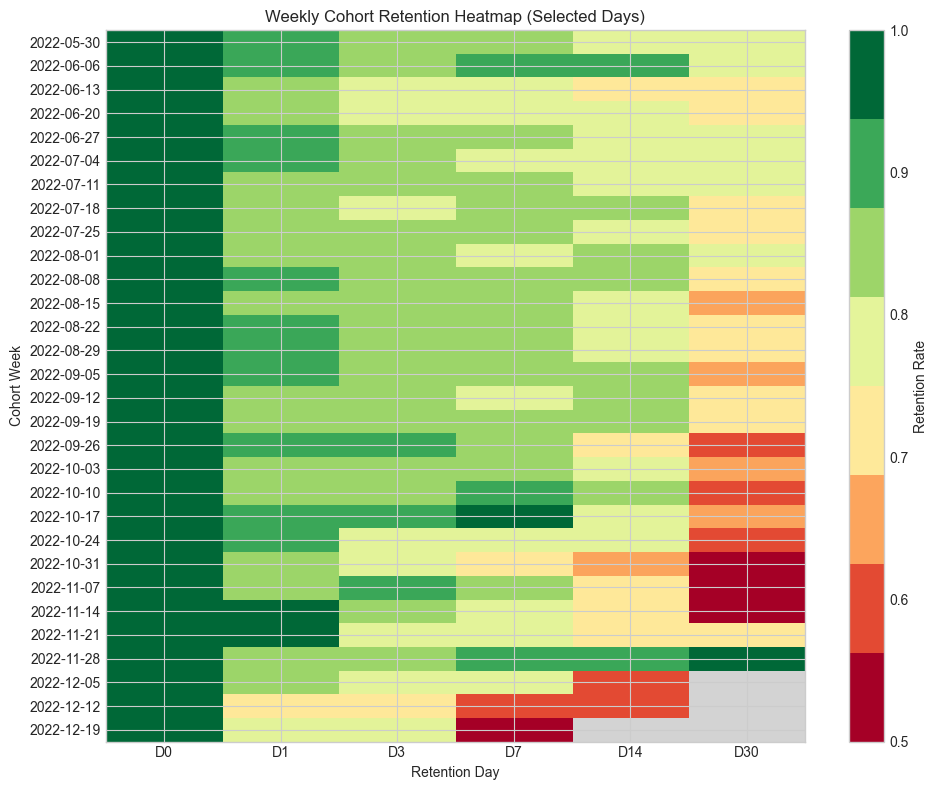

In [21]:
weekly_retention = calculate_retention_curve(
    retention_users,
    daily_activity,
    session_end,
    group_col='cohort_week',
    max_day=30,
)
weekly_retention['cohort_week_str'] = weekly_retention['cohort_week'].dt.strftime('%Y-%m-%d')

selected_days = [0, 1, 3, 7, 14, 30]
weekly_matrix = (
    weekly_retention[weekly_retention['day'].isin(selected_days)]
    .pivot(index='cohort_week_str', columns='day', values='retention_rate')
    .sort_index()
)

masked_matrix = np.ma.masked_invalid(weekly_matrix.values)
cmap = plt.cm.get_cmap('RdYlGn', 8)
cmap.set_bad(color='lightgray')

valid_values = weekly_matrix.values[~np.isnan(weekly_matrix.values)]
color_min = max(0.50, valid_values.min())
color_max = min(1.00, valid_values.max())

plt.figure(figsize=(10, 8))
plt.imshow(masked_matrix, aspect='auto', cmap=cmap, vmin=color_min, vmax=color_max)
plt.colorbar(label='Retention Rate')
plt.title('Weekly Cohort Retention Heatmap (Selected Days)')
plt.xlabel('Retention Day')
plt.ylabel('Cohort Week')
plt.xticks(range(len(weekly_matrix.columns)), [f'D{day}' for day in weekly_matrix.columns])
plt.yticks(range(len(weekly_matrix.index)), weekly_matrix.index)
plt.tight_layout()
plt.show()


### Comment

- From D1 to D14, many cohorts still stay in the green and yellow range, so short-term and mid-term retention look fairly strong.
- D30 becomes weaker for many later cohorts, and the last rows also have missing cells because those cohorts are too new for long-term retention.

## 7. Retention by OS

OS is a basic but useful segment for retention analysis in a mobile game.


,os,day,eligible_users,retained_users,retention_rate_pct
1,Android,1,2973,2563,86.20
7,Android,7,2970,2432,81.90
14,Android,14,2966,2336,78.80
30,Android,30,2935,2064,70.30
32,iOS,1,1295,1148,88.60
38,iOS,7,1295,1087,83.90
45,iOS,14,1295,1055,81.50
61,iOS,30,1293,968,74.90


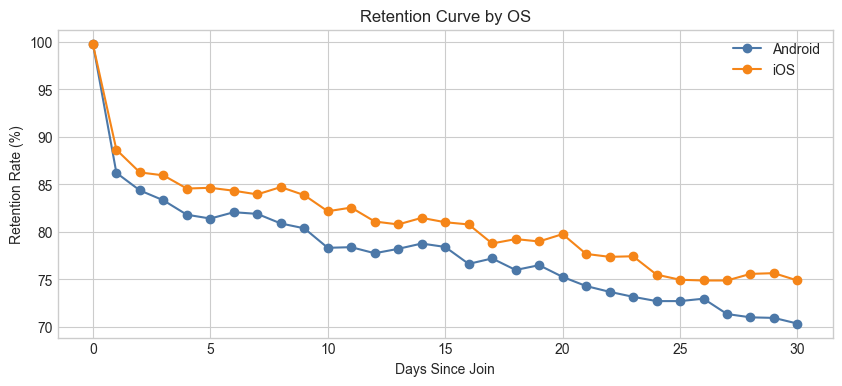

In [22]:
os_retention = calculate_retention_curve(
    retention_users,
    daily_activity,
    session_end,
    group_col='os',
    max_day=30,
)

os_milestones = format_retention_table(
    os_retention[os_retention['day'].isin([1, 7, 14, 30])],
    group_cols=['os']
)

display(os_milestones)

plt.figure(figsize=(10, 4))
for os_name, color in [('Android', '#4C78A8'), ('iOS', '#F58518')]:
    subset = os_retention[os_retention['os'] == os_name]
    plt.plot(subset['day'], subset['retention_rate'] * 100, marker='o', label=os_name, color=color)

plt.title('Retention Curve by OS')
plt.xlabel('Days Since Join')
plt.ylabel('Retention Rate (%)')
plt.legend()
plt.show()


### Comment

- iOS stays above Android through almost the full retention curve. The gap is small but consistent. This suggests iOS users in this dataset come back a little more consistently than Android users.
- A few possible reasons are user mix, acquisition quality, device experience, or market mix inside each OS group. For example, if iOS users come more from stronger countries or stronger acquisition channels, retention can look better even without a product difference.
- Another possible reason is technical experience. If one platform has a smoother session experience, that can support better retention.

## 8. Retention by country

To keep this section readable, I use only the top 5 countries by user count in the retention base.


day,D1,D7,D14,D30
country,,,,
United States,82.30,78.40,75.60,67.50
United Kingdom,86.70,87.70,83.70,75.10
Germany,89.60,82.50,78.90,73.40
Italy,84.00,82.30,84.00,76.80
France,87.80,83.30,76.10,74.20


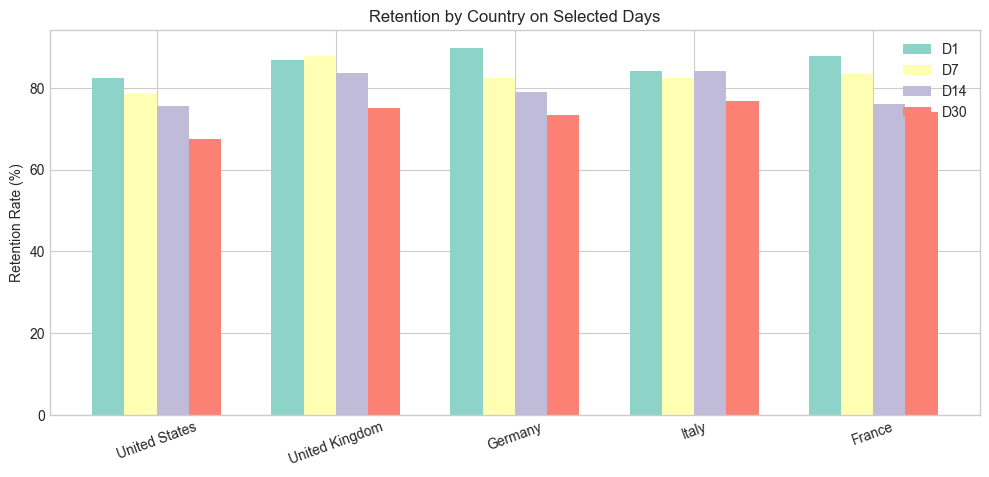

In [23]:
top_countries = retention_users.loc[retention_users['country'] != 'Unknown', 'country'].value_counts().head(5).index.tolist()

country_base = retention_users[retention_users['country'].isin(top_countries)].copy()
country_activity = daily_activity[daily_activity['country'].isin(top_countries)].copy()

country_retention = calculate_retention_curve(
    country_base,
    country_activity,
    session_end,
    group_col='country',
    max_day=30,
)

country_milestones = country_retention[country_retention['day'].isin([1, 7, 14, 30])].copy()
country_table = (
    country_milestones
    .pivot(index='country', columns='day', values='retention_rate')
    .rename(columns=lambda x: f'D{x}')
    .mul(100)
    .round(1)
    .reindex(top_countries)
)

display(country_table)

plot_df = country_table.reset_index()
x = np.arange(len(plot_df))
width = 0.18

plt.figure(figsize=(12, 5))
for idx, col in enumerate(['D1', 'D7', 'D14', 'D30']):
    plt.bar(x + (idx - 1.5) * width, plot_df[col], width=width, label=col)

plt.xticks(x, plot_df['country'], rotation=20)
plt.ylabel('Retention Rate (%)')
plt.title('Retention by Country on Selected Days')
plt.legend()
plt.show()


### Comment

- Retention is not the same across countries. In this top-country view, the United Kingdom and Germany look a bit stronger than the United States on relevant days.

## 9. First-week engagement vs retention

This section checks if stronger early activity is linked with stronger later retention.


In this section, I group users by how many different days they were active in the first 7 days after join.

- `0-1 day` = active on 0 or 1 day in the first week
- `2-3 days` = active on 2 or 3 days in the first week
- `4-5 days` = active on 4 or 5 days in the first week
- `6-7 days` = active on 6 or 7 days in the first week

This uses active days, not session count. If a user opened many sessions on the same day, it still counts as one active day.


,engagement_segment,users
0,0-1 day,111
1,2-3 days,315
2,4-5 days,601
3,6-7 days,3239


day,D7,D14,D30
engagement_segment,,,
0-1 day,17.10,33.60,38.50
2-3 days,35.90,46.50,53.90
4-5 days,68.20,62.50,57.70
6-7 days,91.90,87.50,77.10


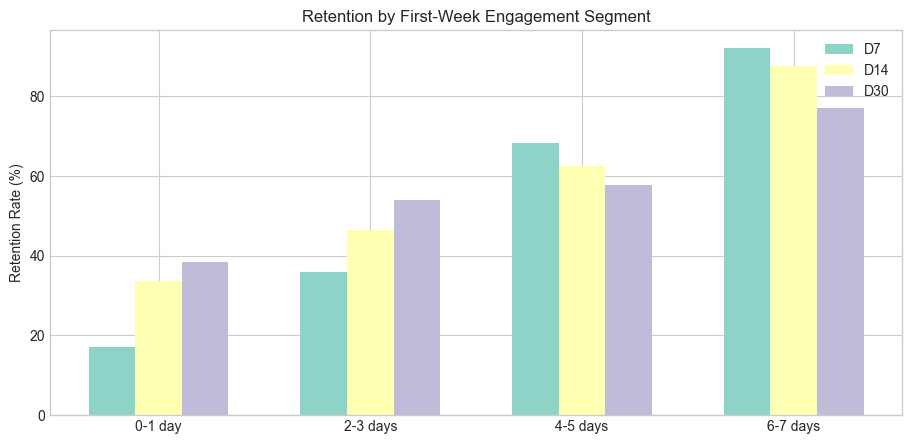

In [24]:
first_week_eligible = retention_users[
    retention_users['join_date'] <= session_end - pd.Timedelta(days=6)
].copy()

first_week_activity = daily_activity[
    daily_activity['user_id'].isin(first_week_eligible['user_id']) &
    daily_activity['days_since_join'].between(0, 6)
].copy()

first_week_summary = first_week_eligible[['user_id']].merge(
    first_week_activity.groupby('user_id').agg(
        first_7d_active_days=('activity_date', 'nunique')
    ).reset_index(),
    on='user_id',
    how='left'
)
first_week_summary['first_7d_active_days'] = first_week_summary['first_7d_active_days'].fillna(0).astype(int)

segment_order = ['0-1 day', '2-3 days', '4-5 days', '6-7 days']
first_week_summary['engagement_segment'] = np.select(
    [
        first_week_summary['first_7d_active_days'] <= 1,
        first_week_summary['first_7d_active_days'].between(2, 3),
        first_week_summary['first_7d_active_days'].between(4, 5),
        first_week_summary['first_7d_active_days'].between(6, 7),
    ],
    segment_order,
    default='0-1 day'
)
first_week_summary['engagement_segment'] = pd.Categorical(
    first_week_summary['engagement_segment'],
    categories=segment_order,
    ordered=True,
)

segment_size_df = (
    first_week_summary['engagement_segment']
    .value_counts()
    .reindex(segment_order)
    .rename_axis('engagement_segment')
    .reset_index(name='users')
)

segment_base = retention_users.merge(
    first_week_summary[['user_id', 'engagement_segment']],
    on='user_id',
    how='inner'
)
segment_activity = daily_activity.merge(
    first_week_summary[['user_id', 'engagement_segment']],
    on='user_id',
    how='inner'
)

segment_retention = calculate_retention_curve(
    segment_base,
    segment_activity,
    session_end,
    group_col='engagement_segment',
    max_day=30,
)

segment_milestones = (
    segment_retention[segment_retention['day'].isin([7, 14, 30])]
    .pivot(index='engagement_segment', columns='day', values='retention_rate')
    .rename(columns=lambda x: f'D{x}')
    .mul(100)
    .round(1)
    .reindex(segment_order)
)

display(segment_size_df)
display(segment_milestones)

plot_df = segment_milestones.reset_index()
x = np.arange(len(plot_df))
width = 0.22

plt.figure(figsize=(11, 5))
for idx, col in enumerate(['D7', 'D14', 'D30']):
    plt.bar(x + (idx - 1) * width, plot_df[col], width=width, label=col)

plt.xticks(x, plot_df['engagement_segment'])
plt.ylabel('Retention Rate (%)')
plt.title('Retention by First-Week Engagement Segment')
plt.legend()
plt.show()


### Comment

- The relationship here is very clear: users with stronger first-week activity have much stronger later retention. The `6-7 days` group is far above the lower activity groups on D7, D14, and D30. This is a strong sign that the first-week experience matters a lot for longer-term retention.


## 10. Key findings

- Overall retention is very high in this dataset. D1 is about 86.9%, D7 is about 82.5%, and D30 is about 71.7%, so these results should be read as dataset-specific, not as a market benchmark.
- Weekly cohorts are fairly strong in many weeks, but later and smaller cohorts look more noisy. Some of the newest cohorts also have missing long-term cells because of the observation window.
- iOS retention stays above Android through almost the full curve. The gap is not large, but it is consistent from early days to D30.
- Country differences are visible. In this top-country view, the United Kingdom and Germany look stronger than the United States on key retention days.
- First-week engagement has the clearest relationship with later retention. Users active on 6 to 7 days in the first week retain much better than the lower-activity groups.
